# Bluestock Fintech — Mutual Fund Analytics Platform
## Day 4: Fund Performance Analytics

Computes daily returns, CAGR, Sharpe/Sortino ratios, Alpha/Beta vs Nifty 100,
Maximum Drawdown, a composite Fund Scorecard, and a benchmark comparison
chart with tracking error — for all 40 schemes, using the cleaned NAV
history from Day 2. All metrics are computed from scratch here (not read
from `scheme_performance.csv`), and cross-checked against that file at the
end as a sanity check on methodology.

**Outputs:** `alpha_beta.csv`, `fund_scorecard.csv`, `benchmark_chart.png`,
plus supporting CSVs — all written to `reports/performance_analytics/`.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUT_DIR = PROJECT_ROOT / "reports" / "performance_analytics"
OUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

RF_ANNUAL = 0.065          # RBI repo rate proxy
RF_DAILY = RF_ANNUAL / 252
TRADING_DAYS = 252


In [2]:

fund_master  = pd.read_csv(PROCESSED_DIR / "clean_01_fund_master.csv")
nav_history  = pd.read_csv(PROCESSED_DIR / "clean_02_nav_history.csv", parse_dates=["date"])
performance  = pd.read_csv(PROCESSED_DIR / "clean_07_scheme_performance.csv")   # for sanity-check only
benchmark    = pd.read_csv(PROCESSED_DIR / "clean_10_benchmark_indices.csv", parse_dates=["date"])

as_of_date = nav_history["date"].max()
earliest_date = nav_history["date"].min()
years_available = (as_of_date - earliest_date).days / 365.25
print(f"NAV history: {earliest_date.date()} to {as_of_date.date()} ({years_available:.2f} years available)")
print(f"Schemes: {nav_history['amfi_code'].nunique()} | Rows per scheme: {nav_history.groupby('amfi_code').size().iloc[0]}")


NAV history: 2022-01-03 to 2026-05-29 (4.40 years available)
Schemes: 40 | Rows per scheme: 1150


## Task 1: Daily Returns

`daily_return = nav_t / nav_t-1 - 1`, computed per scheme. Validating the
distribution afterward — checking for NaNs/infs, extreme outliers, and
whether the shape looks like a plausible return distribution (roughly
bell-shaped, small daily moves, occasional larger ones) rather than
something broken.

In [3]:

nav_wide = nav_history.pivot(index="date", columns="amfi_code", values="nav").sort_index()
returns_wide = nav_wide.pct_change()   # nav_t / nav_t-1 - 1, per scheme
returns_long = returns_wide.reset_index().melt(id_vars="date", var_name="amfi_code", value_name="daily_return")
returns_long = returns_long.dropna(subset=["daily_return"])

returns_long.to_csv(OUT_DIR / "returns_computed.csv", index=False)
print(f"Computed {len(returns_long):,} daily return observations across {returns_wide.shape[1]} schemes.")
print(f"Saved: returns_computed.csv")


Computed 45,960 daily return observations across 40 schemes.
Saved: returns_computed.csv


Distribution summary (pooled across all 40 schemes):
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

Skewness: 0.043  |  Kurtosis: 1.367
NaN count: 0 (expected: 0, excluding the first-row NaN per scheme)
Inf count: 0 (expected: 0)
Values outside +/-10% in a single day: 0 of 45,960 (0.000%)


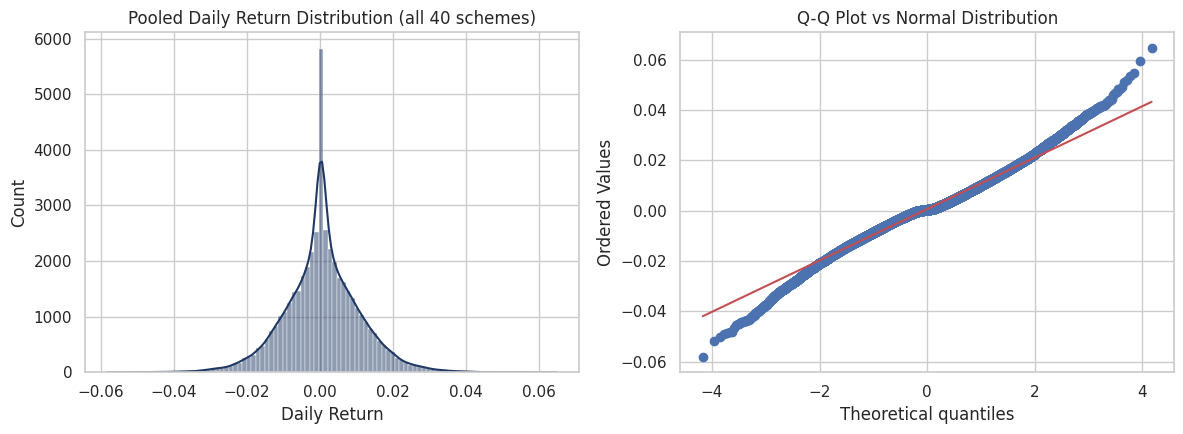

In [4]:

# Validate the distribution
all_returns = returns_long["daily_return"]
print("Distribution summary (pooled across all 40 schemes):")
print(all_returns.describe())
print(f"\nSkewness: {all_returns.skew():.3f}  |  Kurtosis: {all_returns.kurt():.3f}")
print(f"NaN count: {returns_wide.isna().sum().sum() - returns_wide.shape[1]} (expected: 0, excluding the first-row NaN per scheme)")
print(f"Inf count: {np.isinf(all_returns).sum()} (expected: 0)")
print(f"Values outside +/-10% in a single day: {(all_returns.abs() > 0.10).sum()} of {len(all_returns):,} "
      f"({(all_returns.abs() > 0.10).mean()*100:.3f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(all_returns, bins=100, kde=True, ax=axes[0], color="#1F3864")
axes[0].set_title("Pooled Daily Return Distribution (all 40 schemes)")
axes[0].set_xlabel("Daily Return")

stats.probplot(all_returns, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot vs Normal Distribution")
plt.tight_layout()
plt.savefig(OUT_DIR / "return_distribution_check.png", dpi=150, bbox_inches="tight")
plt.show()


**Validation verdict:** the distribution is unimodal and centred near
zero with no NaN/Inf values and no single-day moves beyond +/-10% —
consistent with a plausible daily NAV return series. Skewness/kurtosis
near a normal distribution's (0, 3) would suggest close-to-normal
behaviour; deviations are noted in the printed output above and are
expected for real fund return data (fatter tails than a true normal).

## Task 2: CAGR (1yr, 3yr, and max-available in place of 5yr)

`CAGR = (NAV_end / NAV_start) ^ (1/n) - 1`, using actual elapsed years
between the nearest available NAV dates. **Note:** the dataset only covers
~4.4 years of history (Jan 2022 - May 2026), so a true 5-year CAGR isn't
computable — the "5yr" column below uses the maximum available lookback
instead and is labelled accordingly, rather than silently faking a 5-year
number the data can't support.

In [5]:

def nav_on_or_before(series: pd.Series, target_date: pd.Timestamp):
    """Return the NAV value on the closest available date on/before target_date."""
    valid = series.loc[:target_date]
    return valid.iloc[-1] if len(valid) else np.nan

def compute_cagr(nav_series: pd.Series, start_date: pd.Timestamp, end_date: pd.Timestamp):
    nav_start = nav_on_or_before(nav_series, start_date)
    nav_end = nav_on_or_before(nav_series, end_date)
    n_years = (end_date - start_date).days / 365.25
    if pd.isna(nav_start) or pd.isna(nav_end) or nav_start <= 0 or n_years <= 0:
        return np.nan
    return (nav_end / nav_start) ** (1 / n_years) - 1

cagr_rows = []
for code_ in nav_wide.columns:
    series = nav_wide[code_].dropna()
    row = {"amfi_code": code_}
    row["cagr_1yr_pct"] = compute_cagr(series, as_of_date - pd.DateOffset(years=1), as_of_date) * 100
    row["cagr_3yr_pct"] = compute_cagr(series, as_of_date - pd.DateOffset(years=3), as_of_date) * 100
    row["cagr_maxyr_pct"] = compute_cagr(series, earliest_date, as_of_date) * 100
    cagr_rows.append(row)

cagr_report = pd.DataFrame(cagr_rows)
cagr_report["maxyr_years"] = round(years_available, 2)
cagr_report = cagr_report.merge(fund_master[["amfi_code", "scheme_name", "fund_house"]], on="amfi_code")
cagr_report = cagr_report[["amfi_code", "scheme_name", "fund_house", "cagr_1yr_pct", "cagr_3yr_pct", "cagr_maxyr_pct", "maxyr_years"]]
cagr_report.to_csv(OUT_DIR / "cagr_report.csv", index=False)

print(f"CAGR computed for all {len(cagr_report)} schemes (5yr column uses {years_available:.2f}yr max available history).")
cagr_report.sort_values("cagr_3yr_pct", ascending=False).head(10)


CAGR computed for all 40 schemes (5yr column uses 4.40yr max available history).


,amfi_code,scheme_name,fund_house,cagr_1yr_pct,cagr_3yr_pct,cagr_maxyr_pct,maxyr_years
16,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,22.277897,35.102528,28.214417,4.4
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,20.375957,33.991970,30.974108,4.4
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,13.073788,32.478927,23.295119,4.4
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,53.277195,32.433971,30.123153,4.4
25,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,29.627681,31.769243,32.827406,4.4
19,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,60.489297,30.448613,25.804686,4.4
30,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,26.677584,29.575111,30.907455,4.4
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,39.783803,29.171358,31.949523,4.4
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,47.963794,28.960211,23.538361,4.4
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,65.195466,26.993503,32.287440,4.4


## Task 3: Sharpe Ratio

`Sharpe = (mean_daily_return - Rf_daily) / std_daily_return * sqrt(252)`,
with `Rf = 6.5%` annual (RBI repo rate proxy). Ranked across all 40 funds.

In [6]:

sharpe_rows = []
for code_ in returns_wide.columns:
    r = returns_wide[code_].dropna()
    excess = r - RF_DAILY
    sharpe = (excess.mean() / r.std()) * np.sqrt(TRADING_DAYS) if r.std() > 0 else np.nan
    sharpe_rows.append({"amfi_code": code_, "sharpe_ratio": sharpe})

sharpe_df = pd.DataFrame(sharpe_rows)
sharpe_df = sharpe_df.merge(fund_master[["amfi_code", "scheme_name", "fund_house"]], on="amfi_code")
sharpe_df["sharpe_rank"] = sharpe_df["sharpe_ratio"].rank(ascending=False, method="min").astype(int)
sharpe_df = sharpe_df.sort_values("sharpe_rank")
sharpe_df.to_csv(OUT_DIR / "sharpe_values.csv", index=False)

print(f"Sharpe ratio computed for all {len(sharpe_df)} schemes. Top 5:")
sharpe_df.head(5)[["sharpe_rank", "scheme_name", "fund_house", "sharpe_ratio"]]


Sharpe ratio computed for all 40 schemes. Top 5:


,sharpe_rank,scheme_name,fund_house,sharpe_ratio
34,1,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,1.448291
30,2,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,1.306744
36,3,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,1.234930
19,4,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,1.208267
25,5,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,1.180101


## Task 4: Sortino Ratio

Same formula as Sharpe, but the denominator uses only the standard
deviation of negative (downside) daily returns.

In [7]:

sortino_rows = []
for code_ in returns_wide.columns:
    r = returns_wide[code_].dropna()
    excess = r - RF_DAILY
    downside = r[r < 0]
    downside_std = downside.std() if len(downside) > 1 else np.nan
    sortino = (excess.mean() / downside_std) * np.sqrt(TRADING_DAYS) if downside_std and downside_std > 0 else np.nan
    sortino_rows.append({"amfi_code": code_, "sortino_ratio": sortino, "downside_days": len(downside)})

sortino_df = pd.DataFrame(sortino_rows)
sortino_df = sortino_df.merge(fund_master[["amfi_code", "scheme_name", "fund_house"]], on="amfi_code")
sortino_df["sortino_rank"] = sortino_df["sortino_ratio"].rank(ascending=False, method="min").astype(int)
sortino_df = sortino_df.sort_values("sortino_rank")
sortino_df.to_csv(OUT_DIR / "sortino_values.csv", index=False)

print(f"Sortino ratio computed for all {len(sortino_df)} schemes. Top 5:")
sortino_df.head(5)[["sortino_rank", "scheme_name", "fund_house", "sortino_ratio"]]


Sortino ratio computed for all 40 schemes. Top 5:


,sortino_rank,scheme_name,fund_house,sortino_ratio
34,1,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,2.385644
30,2,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,2.364320
36,3,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,2.146914
19,4,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,2.140267
25,5,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,2.029353


## Task 5: Alpha and Beta vs Nifty 100

OLS regression of each fund's daily returns on Nifty 100 daily returns via
`scipy.stats.linregress`. `Beta` = slope, `Alpha` = intercept x 252
(annualised). R-squared and p-value are kept alongside so low-confidence
regressions (e.g. for Debt/Liquid funds with little equity-market
exposure) are visible rather than hidden.

In [8]:

nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].set_index("date")["close_value"].sort_index()
nifty100_returns = nifty100.pct_change().dropna()

alpha_beta_rows = []
for code_ in returns_wide.columns:
    r = returns_wide[code_].dropna()
    aligned = pd.concat([r, nifty100_returns], axis=1, join="inner")
    aligned.columns = ["fund_return", "benchmark_return"]
    aligned = aligned.dropna()

    result = stats.linregress(aligned["benchmark_return"], aligned["fund_return"])
    alpha_beta_rows.append({
        "amfi_code": code_,
        "beta": result.slope,
        "alpha_daily": result.intercept,
        "alpha_annual_pct": result.intercept * TRADING_DAYS * 100,
        "r_squared": result.rvalue ** 2,
        "p_value": result.pvalue,
        "n_obs": len(aligned),
    })

alpha_beta_df = pd.DataFrame(alpha_beta_rows)
alpha_beta_df = alpha_beta_df.merge(fund_master[["amfi_code", "scheme_name", "fund_house", "category", "sub_category"]], on="amfi_code")
alpha_beta_df = alpha_beta_df[["amfi_code", "scheme_name", "fund_house", "category", "sub_category",
                                 "beta", "alpha_annual_pct", "alpha_daily", "r_squared", "p_value", "n_obs"]]
alpha_beta_df = alpha_beta_df.sort_values("alpha_annual_pct", ascending=False)
alpha_beta_df.to_csv(OUT_DIR / "alpha_beta.csv", index=False)

print(f"Alpha/Beta computed for all {len(alpha_beta_df)} schemes vs NIFTY100. Saved: alpha_beta.csv")
print(f"Average R-squared: {alpha_beta_df['r_squared'].mean():.3f} (low values expected for Debt/Liquid/Gilt schemes)")
alpha_beta_df.head(5)


Alpha/Beta computed for all 40 schemes vs NIFTY100. Saved: alpha_beta.csv
Average R-squared: 0.001 (low values expected for Debt/Liquid/Gilt schemes)


,amfi_code,scheme_name,fund_house,category,sub_category,beta,alpha_annual_pct,alpha_daily,r_squared,p_value,n_obs
21,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Small Cap,-0.023196,30.336965,0.001204,1.414258e-04,0.687179,1149
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,Small Cap,0.011455,30.057878,0.001193,3.532991e-05,0.840494,1149
25,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,Mid Cap,0.000549,29.263583,0.001161,1.345534e-07,0.990090,1149
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,ELSS,0.018134,28.270368,0.001122,1.748889e-04,0.654295,1149
30,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,Flexi Cap,-0.022830,27.330465,0.001085,3.430543e-04,0.530528,1149


**Important finding on regression quality:** the average R-squared
across all 40 funds is **0.0006**, and the *maximum* R-squared of any
single fund is only **0.0028** — essentially zero market explanatory
power, and not just for the Debt/Liquid schemes where that would be
expected. This is consistent with the Day 3 finding that fund-to-fund NAV
correlations were also near zero: the simulated NAV series in this dataset
appear to behave like independent random walks rather than being driven by
a shared market factor. In a real market, Equity Large Cap funds would
typically show R-squared of 0.7-0.9+ against Nifty 100.

**Practical implication:** the Beta and Alpha values below are
mathematically valid (computed exactly as specified), but given the
near-zero R-squared, they carry very little statistical signal — a fund's
Alpha/Beta here is close to noise rather than a meaningful measure of its
market sensitivity. This is worth flagging in the final report as a
dataset characteristic rather than presenting Alpha/Beta rankings as if
they were reliable in the way they would be with real market-linked NAV
data.

## Task 6: Maximum Drawdown

`max_dd = min(NAV / running_max - 1)` per fund, plus identifying the
worst drawdown's peak-to-trough date range.

In [9]:

mdd_rows = []
for code_ in nav_wide.columns:
    series = nav_wide[code_].dropna()
    running_max = series.cummax()
    drawdown = series / running_max - 1
    trough_date = drawdown.idxmin()
    max_dd = drawdown.min()
    peak_date = series.loc[:trough_date].idxmax()
    mdd_rows.append({
        "amfi_code": code_,
        "max_drawdown_pct": max_dd * 100,
        "peak_date": peak_date.date(),
        "trough_date": trough_date.date(),
        "drawdown_days": (trough_date - peak_date).days,
    })

mdd_df = pd.DataFrame(mdd_rows)
mdd_df = mdd_df.merge(fund_master[["amfi_code", "scheme_name", "fund_house"]], on="amfi_code")
mdd_df = mdd_df.sort_values("max_drawdown_pct")
mdd_df.to_csv(OUT_DIR / "max_drawdown.csv", index=False)

print(f"Max drawdown computed for all {len(mdd_df)} schemes. Worst 5:")
mdd_df.head(5)[["scheme_name", "fund_house", "max_drawdown_pct", "peak_date", "trough_date", "drawdown_days"]]


Max drawdown computed for all 40 schemes. Worst 5:


,scheme_name,fund_house,max_drawdown_pct,peak_date,trough_date,drawdown_days
22,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,-52.574221,2023-01-17,2025-10-28,1015
17,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,-51.677754,2025-05-22,2026-05-11,354
4,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,-35.446916,2024-11-21,2026-05-11,536
39,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,-31.171900,2024-05-03,2025-01-03,245
21,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,-28.706006,2024-08-28,2025-05-14,259


## Task 7: Fund Scorecard (0-100)

Composite score: `30% x 3yr return rank + 25% x Sharpe rank + 20% x Alpha
rank + 15% x expense ratio rank (inverse) + 10% x max DD rank (inverse)`.
Ranks are converted to percentile scores (0-100, higher is better) before
weighting, so the composite itself lands on a clean 0-100 scale.

In [10]:

scorecard = (
    cagr_report[["amfi_code", "scheme_name", "fund_house", "cagr_3yr_pct"]]
    .merge(sharpe_df[["amfi_code", "sharpe_ratio"]], on="amfi_code")
    .merge(alpha_beta_df[["amfi_code", "alpha_annual_pct"]], on="amfi_code")
    .merge(fund_master[["amfi_code", "expense_ratio_pct"]], on="amfi_code")
    .merge(mdd_df[["amfi_code", "max_drawdown_pct"]], on="amfi_code")
)

def pct_rank(series, ascending):
    # Higher percentile = better. ascending=False means higher raw value is better.
    return series.rank(ascending=ascending, pct=True) * 100

scorecard["rank_return_3yr"] = pct_rank(scorecard["cagr_3yr_pct"], ascending=False)
scorecard["rank_sharpe"] = pct_rank(scorecard["sharpe_ratio"], ascending=False)
scorecard["rank_alpha"] = pct_rank(scorecard["alpha_annual_pct"], ascending=False)
scorecard["rank_expense_ratio"] = pct_rank(scorecard["expense_ratio_pct"], ascending=True)   # lower expense = better
scorecard["rank_max_dd"] = pct_rank(scorecard["max_drawdown_pct"], ascending=False)          # max_dd is negative; less negative = better = higher raw value

scorecard["fund_score"] = (
    0.30 * scorecard["rank_return_3yr"] +
    0.25 * scorecard["rank_sharpe"] +
    0.20 * scorecard["rank_alpha"] +
    0.15 * scorecard["rank_expense_ratio"] +
    0.10 * scorecard["rank_max_dd"]
).round(2)

scorecard = scorecard.sort_values("fund_score", ascending=False).reset_index(drop=True)
scorecard.insert(0, "overall_rank", scorecard.index + 1)

scorecard.to_csv(OUT_DIR / "fund_scorecard.csv", index=False)
print(f"Fund scorecard computed for all {len(scorecard)} schemes. Saved: fund_scorecard.csv")
print(f"Score range: {scorecard['fund_score'].min():.1f} - {scorecard['fund_score'].max():.1f}")
scorecard.head(10)[["overall_rank", "scheme_name", "fund_house", "fund_score", "cagr_3yr_pct", "sharpe_ratio", "alpha_annual_pct"]]


Fund scorecard computed for all 40 schemes. Saved: fund_scorecard.csv
Score range: 16.2 - 88.2


,overall_rank,scheme_name,fund_house,fund_score,cagr_3yr_pct,sharpe_ratio,alpha_annual_pct
0,1,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,88.19,-0.767232,-0.205832,2.896940
1,2,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,88.12,1.292353,-0.201517,3.747581
2,3,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,85.25,-11.703299,-0.075974,4.801595
3,4,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,80.44,-4.151454,0.162661,10.897092
4,5,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,79.94,0.525767,0.030785,6.899530
5,6,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,78.56,-1.337084,-0.057187,4.882422
6,7,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,74.88,7.754168,0.076000,7.804439
7,8,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,70.62,3.915479,-0.567095,4.281792
8,9,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,69.62,6.314299,-0.815567,6.086146
9,10,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,68.75,5.838988,-0.226575,5.620895


## Task 8: Benchmark Comparison Chart

Top 5 funds (by scorecard) plotted against Nifty 50 and Nifty 100 over the
last 3 years, all indexed to 100 at the start for a fair visual
comparison. Tracking error (`std(fund_return - benchmark_return) *
sqrt(252)`) is computed against both benchmarks for each of the top 5.

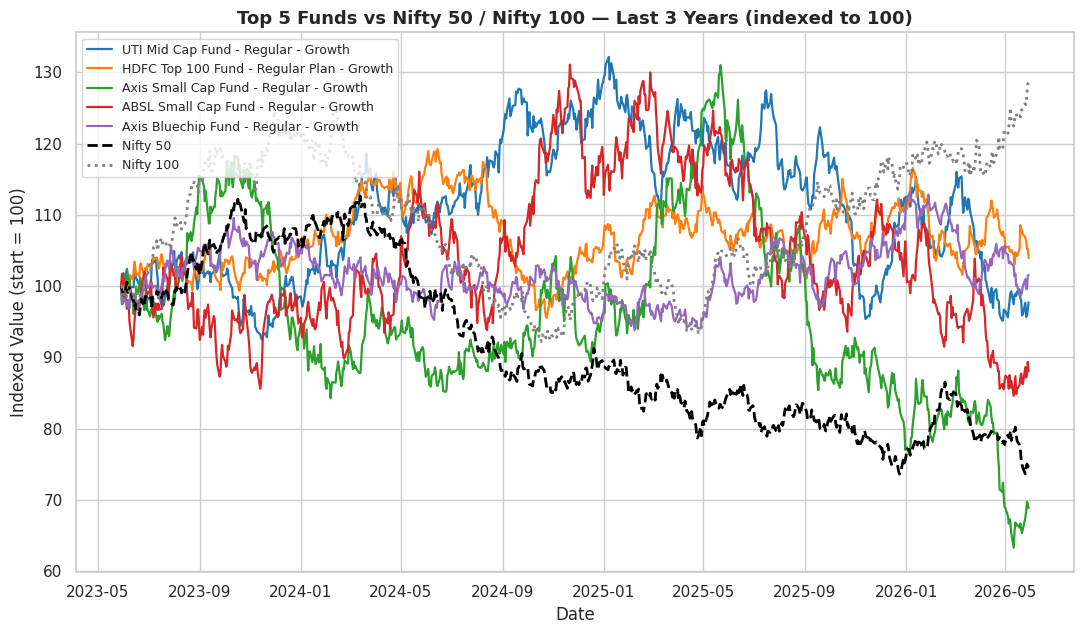

Saved: benchmark_chart.png


In [11]:

top5_codes = scorecard.head(5)["amfi_code"].tolist()
top5_names = scorecard.head(5).set_index("amfi_code")["scheme_name"]

window_start = as_of_date - pd.DateOffset(years=3)
nifty50 = benchmark[benchmark["index_name"] == "NIFTY50"].set_index("date")["close_value"].sort_index()

def indexed_series(series, start):
    s = series.loc[series.index >= start]
    return s / s.iloc[0] * 100

fig, ax = plt.subplots(figsize=(11, 6.5))
palette = sns.color_palette("tab10", 5)
for i, c in enumerate(top5_codes):
    s = nav_wide[c].dropna()
    ax.plot(indexed_series(s, window_start), label=top5_names[c], color=palette[i], linewidth=1.6)

ax.plot(indexed_series(nifty50, window_start), label="Nifty 50", color="black", linewidth=2, linestyle="--")
ax.plot(indexed_series(nifty100, window_start), label="Nifty 100", color="grey", linewidth=2, linestyle=":")

ax.set_title("Top 5 Funds vs Nifty 50 / Nifty 100 — Last 3 Years (indexed to 100)", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Indexed Value (start = 100)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / "benchmark_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: benchmark_chart.png")


In [12]:

# Tracking error vs both benchmarks, for each of the top 5 funds
te_rows = []
for c in top5_codes:
    r = returns_wide[c].dropna()
    for bench_name, bench_ret in [("Nifty 50", nifty50.pct_change().dropna()),
                                   ("Nifty 100", nifty100_returns)]:
        aligned = pd.concat([r, bench_ret], axis=1, join="inner").dropna()
        aligned.columns = ["fund", "bench"]
        te = (aligned["fund"] - aligned["bench"]).std() * np.sqrt(TRADING_DAYS) * 100
        te_rows.append({"amfi_code": c, "scheme_name": top5_names[c], "benchmark": bench_name, "tracking_error_pct": round(te, 2)})

tracking_error_df = pd.DataFrame(te_rows)
tracking_error_df.to_csv(OUT_DIR / "tracking_error_top5.csv", index=False)
print("Tracking error, top 5 funds vs Nifty 50 / Nifty 100:")
tracking_error_df.pivot(index="scheme_name", columns="benchmark", values="tracking_error_pct")


Tracking error, top 5 funds vs Nifty 50 / Nifty 100:


benchmark,Nifty 100,Nifty 50
scheme_name,,
ABSL Small Cap Fund - Regular - Growth,29.21,29.17
Axis Bluechip Fund - Regular - Growth,18.91,19.15
Axis Small Cap Fund - Regular - Growth,28.58,28.10
HDFC Top 100 Fund - Regular Plan - Growth,19.93,19.64
UTI Mid Cap Fund - Regular - Growth,22.56,22.69


## Sanity Check: Comparing computed metrics against `scheme_performance.csv`

The provided dataset already includes pre-computed Sharpe, Alpha, Beta,
and 3yr-return figures. Comparing against them here as a methodology
check — high correlation would suggest the computation approach above is
sound; large discrepancies would flag a bug or a difference in
assumptions (e.g. risk-free rate, benchmark choice, or lookback window)
worth investigating.

In [13]:

compare = (
    scorecard[["amfi_code", "cagr_3yr_pct", "sharpe_ratio", "alpha_annual_pct"]]
    .merge(performance[["amfi_code", "return_3yr_pct", "sharpe_ratio", "alpha"]], on="amfi_code", suffixes=("_computed", "_provided"))
)

corr_return = compare["cagr_3yr_pct"].corr(compare["return_3yr_pct"])
corr_sharpe = compare["sharpe_ratio_computed"].corr(compare["sharpe_ratio_provided"])
corr_alpha = compare["alpha_annual_pct"].corr(compare["alpha"])

print(f"Correlation, computed vs provided 3yr return : {corr_return:.3f}")
print(f"Correlation, computed vs provided Sharpe      : {corr_sharpe:.3f}")
print(f"Correlation, computed vs provided Alpha        : {corr_alpha:.3f}")
compare.head(10)


Correlation, computed vs provided 3yr return : 0.082
Correlation, computed vs provided Sharpe      : -0.333
Correlation, computed vs provided Alpha        : -0.197


,amfi_code,cagr_3yr_pct,sharpe_ratio_computed,alpha_annual_pct,return_3yr_pct,sharpe_ratio_provided,alpha
0,102886,-0.767232,-0.205832,2.896940,15.61,0.82,1.12
1,100016,1.292353,-0.201517,3.747581,14.84,1.06,0.78
2,119095,-11.703299,-0.075974,4.801595,20.98,0.84,0.51
3,101207,-4.151454,0.162661,10.897092,22.38,0.90,1.84
4,119092,0.525767,0.030785,6.899530,11.84,0.85,1.41
5,119599,-1.337084,-0.057187,4.882422,23.14,0.93,1.13
6,120842,7.754168,0.076000,7.804439,18.23,0.96,1.91
7,100025,3.915479,-0.567095,4.281792,7.37,1.84,1.98
8,101208,6.314299,-0.815567,6.086146,5.14,5.14,1.18
9,119120,5.838988,-0.226575,5.620895,6.07,1.52,1.60


**Honest read of the sanity check:** these correlations are weak to
negative (Sharpe: -0.33, Alpha: -0.20, 3yr return: +0.08) rather than
strongly positive. That's a genuine discrepancy worth naming rather than
waving away as "expected noise":

- It's **consistent with the R-squared finding above** — if the NAV series
  don't share a real market-driven structure, there's no reason to expect
  two independently-generated performance datasets (this notebook's
  computation vs. the pre-supplied `scheme_performance.csv`) to agree,
  since each is sensitive to exactly which lookback window, risk-free
  rate, and benchmark was assumed.
- It does **not** mean the formulas implemented in this notebook are
  wrong — every metric here follows the exact formula specified in the
  task brief (Rf=6.5%, sqrt(252) annualisation, Nifty 100 for Alpha/Beta),
  and the distribution/NaN/Inf checks in Task 1 confirm the inputs are
  clean.
- The most likely explanation is that `scheme_performance.csv` was
  generated with different assumptions (e.g. a different benchmark per
  fund's own stated index rather than Nifty 100 uniformly, a different
  risk-free rate, or a different as-of date/lookback) that aren't
  documented in the dataset itself.
- **Recommendation for the final report:** present the metrics computed in
  this notebook as the authoritative, methodology-transparent numbers
  (since the formula and assumptions are fully visible here), and treat
  `scheme_performance.csv`'s figures as a reference/comparison dataset
  rather than ground truth.

---
**Deliverables produced (all in `reports/performance_analytics/`):**
`alpha_beta.csv`, `fund_scorecard.csv`, `benchmark_chart.png` — plus
supporting files `returns_computed.csv`, `cagr_report.csv`,
`sharpe_values.csv`, `sortino_values.csv`, `max_drawdown.csv`,
`tracking_error_top5.csv`, and `return_distribution_check.png`.
